In [ ]:
# Restart runtime and run this first
!nvidia-smi

! git clone https://github.com/Mtlukasik/jan2026.git
! mkdir /content/bnn_comparison
! cp -r /content/jan2026/* /content/bnn_comparison
from google.colab import drive
drive.mount('/content/drive')

/bin/bash: line 1: nvidia-smi: command not found
Cloning into 'jan2026'...
remote: Enumerating objects: 112, done.
remote: Counting objects: 100% (112/112), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 112 (delta 60), reused 68 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (112/112), 165.33 KiB | 4.72 MiB/s, done.
Resolving deltas: 100% (60/60), done.
Mounted at /content/drive


Loaded 50 SVGD particles from last_layer_svgd_laplace_std1_T0.1_replicate_1
Loaded existing data split from: /content/drive/MyDrive/bnn_experiments/data_split.json
Data splits:
  Train: 45000 (with augmentation)
  Val:   5000 (no augmentation, for model selection)
  Test:  10000 (held out, NEVER used during training)
  OOD:   26032 (SVHN)
✓ Verified: No data leakage between train/val splits
Loaded 100 test samples (CIFAR-10)
Loaded 100 OOD samples (SVHN)
torch.Size([100, 3, 32, 32])
Loaded 50 SVGD particles from last_layer_svgd_laplace_std1_T0.1_replicate_1
Predictions: tensor([3, 8, 8, 0, 6, 6, 1, 6, 3, 1])
Confidence: tensor([0.9992, 0.9978, 0.9985, 0.9965, 0.9970, 0.9928, 0.9938, 0.9973, 0.9989,
        0.9961])
Epistemic: tensor([0.0001, 0.0005, 0.0002, 0.0004, 0.0003, 0.0007, 0.0007, 0.0003, 0.0001,
        0.0002])
Total entro: tensor([0.0081, 0.0169, 0.0124, 0.0287, 0.0238, 0.0521, 0.0476, 0.0234, 0.0109,
        0.0289])
particle probs: tensor([[[8.7668e-06, 6.7616e-06, 8.6052e

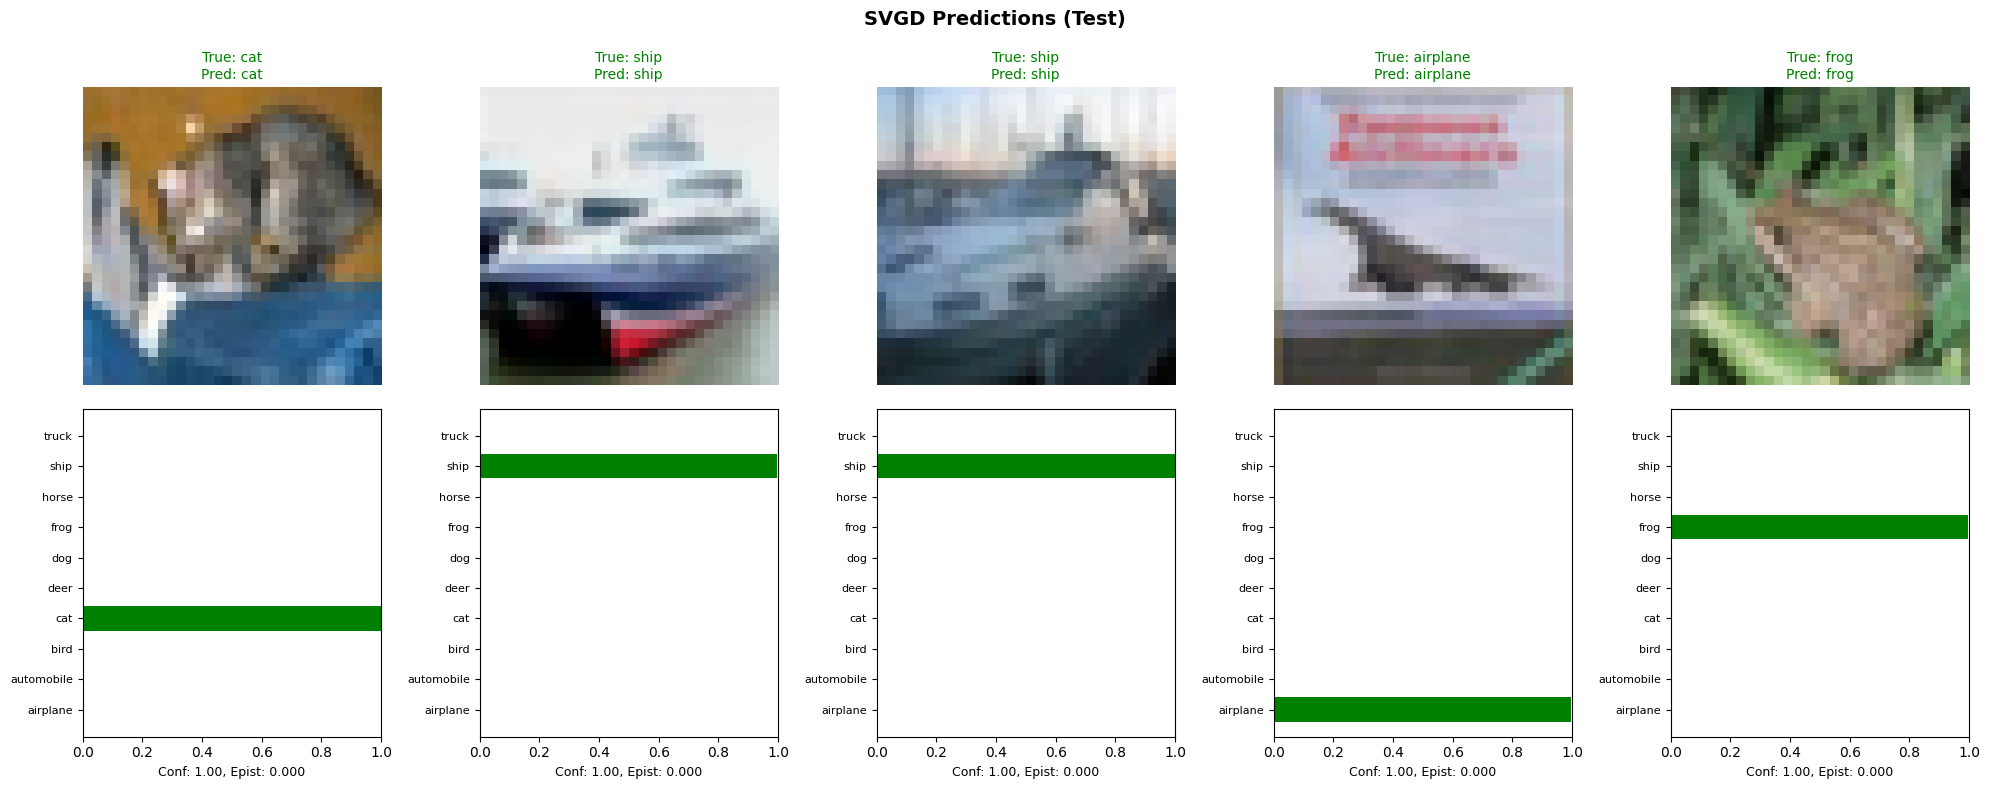

In [ ]:
# Your save directory (adjust path as needed)
save_dir = "/content/drive/MyDrive/bnn_experiments"
from jan2026.analyze_uncertainty import load_svgd_particles, load_mfvi_model

# Load SVGD (new variant format)
fe, particles = load_svgd_particles(
    save_dir,
    variant_name="svgd_laplace_std1",
    temperature=0.1
)
from jan2026.analyze_uncertainty import (
    load_svgd_particles,
    load_mfvi_model,
    load_test_data,
    predict_svgd,
    predict_mfvi,
    show_predictions
)

save_dir = "/content/drive/MyDrive/bnn_experiments"

# 1. Load test data
data = load_test_data(save_dir, n_samples=100)
print(data['test_images'].shape)  # (100, 3, 32, 32)

# 2. Load SVGD model
fe, particles = load_svgd_particles(
    save_dir,
    variant_name="svgd_laplace_std1",  # or prior_type="laplace" for old format
    temperature=0.1
)

# 3. Run predictions
results = predict_svgd(fe, particles, data['test_images'])

print(f"Predictions: {results['predictions'][:10]}")
print(f"Confidence: {results['confidence'][:10]}")
print(f"Epistemic: {results['epistemic'][:10]}")
print(f"Total entro: {results['total_entropy'][:10]}")
print(f"particle probs: {results['particle_probs'][:10]}")
# 4. Visualize
show_predictions(
    data['test_images'][:5],
    data['test_labels'][:5],
    results,
    data['class_names'],
    title="SVGD Predictions (Test)"
)

# 5. Compare test vs OOD
results_test = predict_svgd(fe, particles, data['test_images'])
results_ood = predict_svgd(fe, particles, data['ood_images'])

print(f"\nTest - Mean epistemic: {results_test['epistemic'].mean():.4f}")
print(f"OOD  - Mean epistemic: {results_ood['epistemic'].mean():.4f}")
print(f"Ratio: {results_ood['epistemic'].mean() / results_test['epistemic'].mean():.1f}x")

In [ ]:
results['particle_probs'].shape

torch.Size([50, 100, 10])

Liczba błędów: 4
Pierwsze 10 błędnych indeksów: [47, 52, 58, 61]


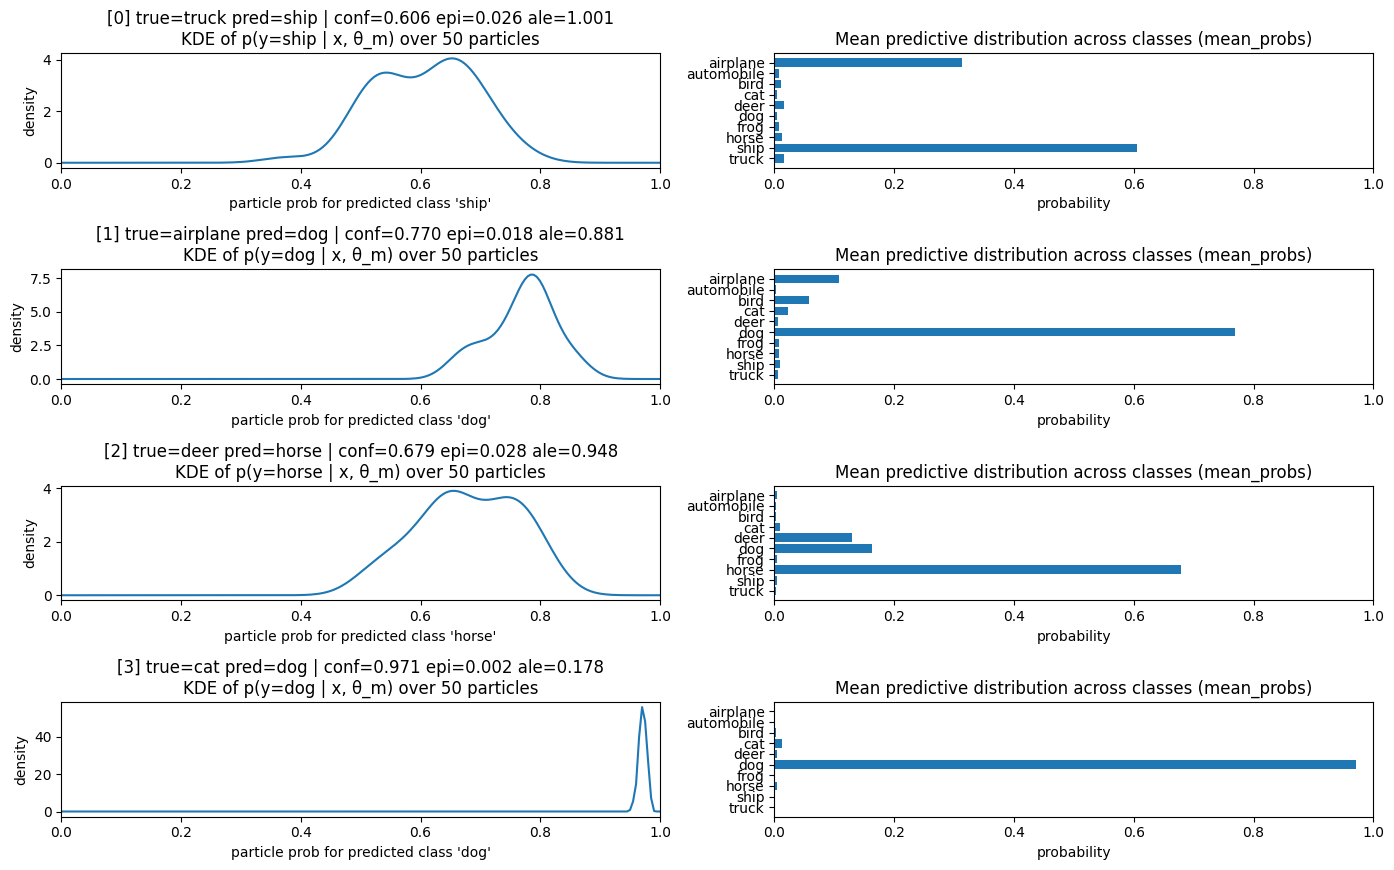

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def _kde_1d(x, grid=None, bw=None):
    """
    Prosty KDE: próbuje scipy, jak nie ma to robi histogram + lekkie wygładzenie.
    Zwraca (grid, density).
    """
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if grid is None:
        grid = np.linspace(0.0, 1.0, 200)

    # 1) SciPy KDE (jeśli dostępne)
    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(x, bw_method=bw)
        return grid, kde(grid)
    except Exception:
        pass

    # 2) Fallback: histogram density + wygładzenie (gaussian conv)
    hist, edges = np.histogram(x, bins=30, range=(0.0, 1.0), density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])

    # proste wygładzenie: splot z małym gaussem
    sigma = 1.5
    radius = int(3 * sigma)
    xs = np.arange(-radius, radius + 1)
    kernel = np.exp(-0.5 * (xs / sigma) ** 2)
    kernel = kernel / kernel.sum()
    smooth = np.convolve(hist, kernel, mode="same")

    # interpolacja na grid
    density = np.interp(grid, centers, smooth, left=0.0, right=0.0)
    return grid, density


def show_svgd_uncertainty_presentation(
    results,
    labels,
    class_names,
    n_show=10,
    topk=10,              # CIFAR-10 => 10
    show_particle_lines=False  # jeśli chcesz, możesz dołożyć pionowe kreski na particle'ach
):
    """
    results: dict z predict_svgd
      - particle_probs: (P, N, C)
      - mean_probs: (N, C)
      - predictions: (N,)
      - epistemic, aleatoric: (N,)
    labels: (N,) tensor
    """

    P, N, C = results["particle_probs"].shape
    n_show = min(n_show, N)
    C = min(C, topk)

    fig, axes = plt.subplots(n_show, 2, figsize=(14, 2.2 * n_show))
    if n_show == 1:
        axes = np.array([axes])

    for i in range(n_show):
        true = int(labels[i].item())
        pred = int(results["predictions"][i].item())

        mean_probs = results["mean_probs"][i, :C].detach().cpu().numpy()
        part_probs = results["particle_probs"][:, i, :C].detach().cpu().numpy()

        # --- LEFT: epistemic KDE for predicted class probability across particles
        ax = axes[i, 0]
        x = part_probs[:, pred]  # (P,)
        grid, dens = _kde_1d(x)

        ax.plot(grid, dens)
        ax.set_xlim(0, 1)
        ax.set_ylabel("density")

        if show_particle_lines:
            for v in x:
                ax.axvline(v, alpha=0.08)

        epi = float(results["epistemic"][i].item())
        ale = float(results["aleatoric"][i].item())
        conf = float(results["confidence"][i].item())

        ax.set_title(
            f"[{i}] true={class_names[true]} pred={class_names[pred]} | "
            f"conf={conf:.3f} epi={epi:.3f} ale={ale:.3f}\n"
            f"KDE of p(y={class_names[pred]} | x, θ_m) over {P} particles"
        )
        ax.set_xlabel(f"particle prob for predicted class '{class_names[pred]}'")

        # --- RIGHT: “aleatoric” presentation = class distribution of mean_probs
        ax = axes[i, 1]
        ax.barh(np.arange(C), mean_probs)
        ax.set_yticks(np.arange(C))
        ax.set_yticklabels(class_names[:C])
        ax.set_xlim(0, 1)
        ax.invert_yaxis()

        ax.set_title("Mean predictive distribution across classes (mean_probs)")
        ax.set_xlabel("probability")

    plt.tight_layout()
    return fig

pred = results["predictions"].detach().cpu()
true = data["test_labels"].detach().cpu()
wrong_idx = (pred != true).nonzero(as_tuple=True)[0]

print("Liczba błędów:", len(wrong_idx))
print("Pierwsze 10 błędnych indeksów:", wrong_idx[:10].tolist())

# weź pierwsze 10 błędnych przykładów i pokaż prezentację
idx10 = wrong_idx[:10]

fig = show_svgd_uncertainty_presentation(
    results={
        **results,
        # pod-tnij wszystko co jest per-sample (N, ...) do wybranych indeksów
        "mean_probs": results["mean_probs"][idx10],
        "particle_probs": results["particle_probs"][:, idx10, :],
        "predictions": results["predictions"][idx10],
        "confidence": results["confidence"][idx10],
        "epistemic": results["epistemic"][idx10],
        "aleatoric": results["aleatoric"][idx10],
        "total_entropy": results["total_entropy"][idx10],
    },
    labels=data["test_labels"][idx10],
    class_names=data["class_names"],
    n_show=len(idx10),
)
plt.show()

Liczba błędów: 89
Pierwsze 10 błędnych indeksów: [0, 1, 2, 4, 5, 6, 7, 8, 9, 11]
H_pred: 13.843372344970703 H_ale: 1.3598766326904297 H_epi: 12.483495712280273


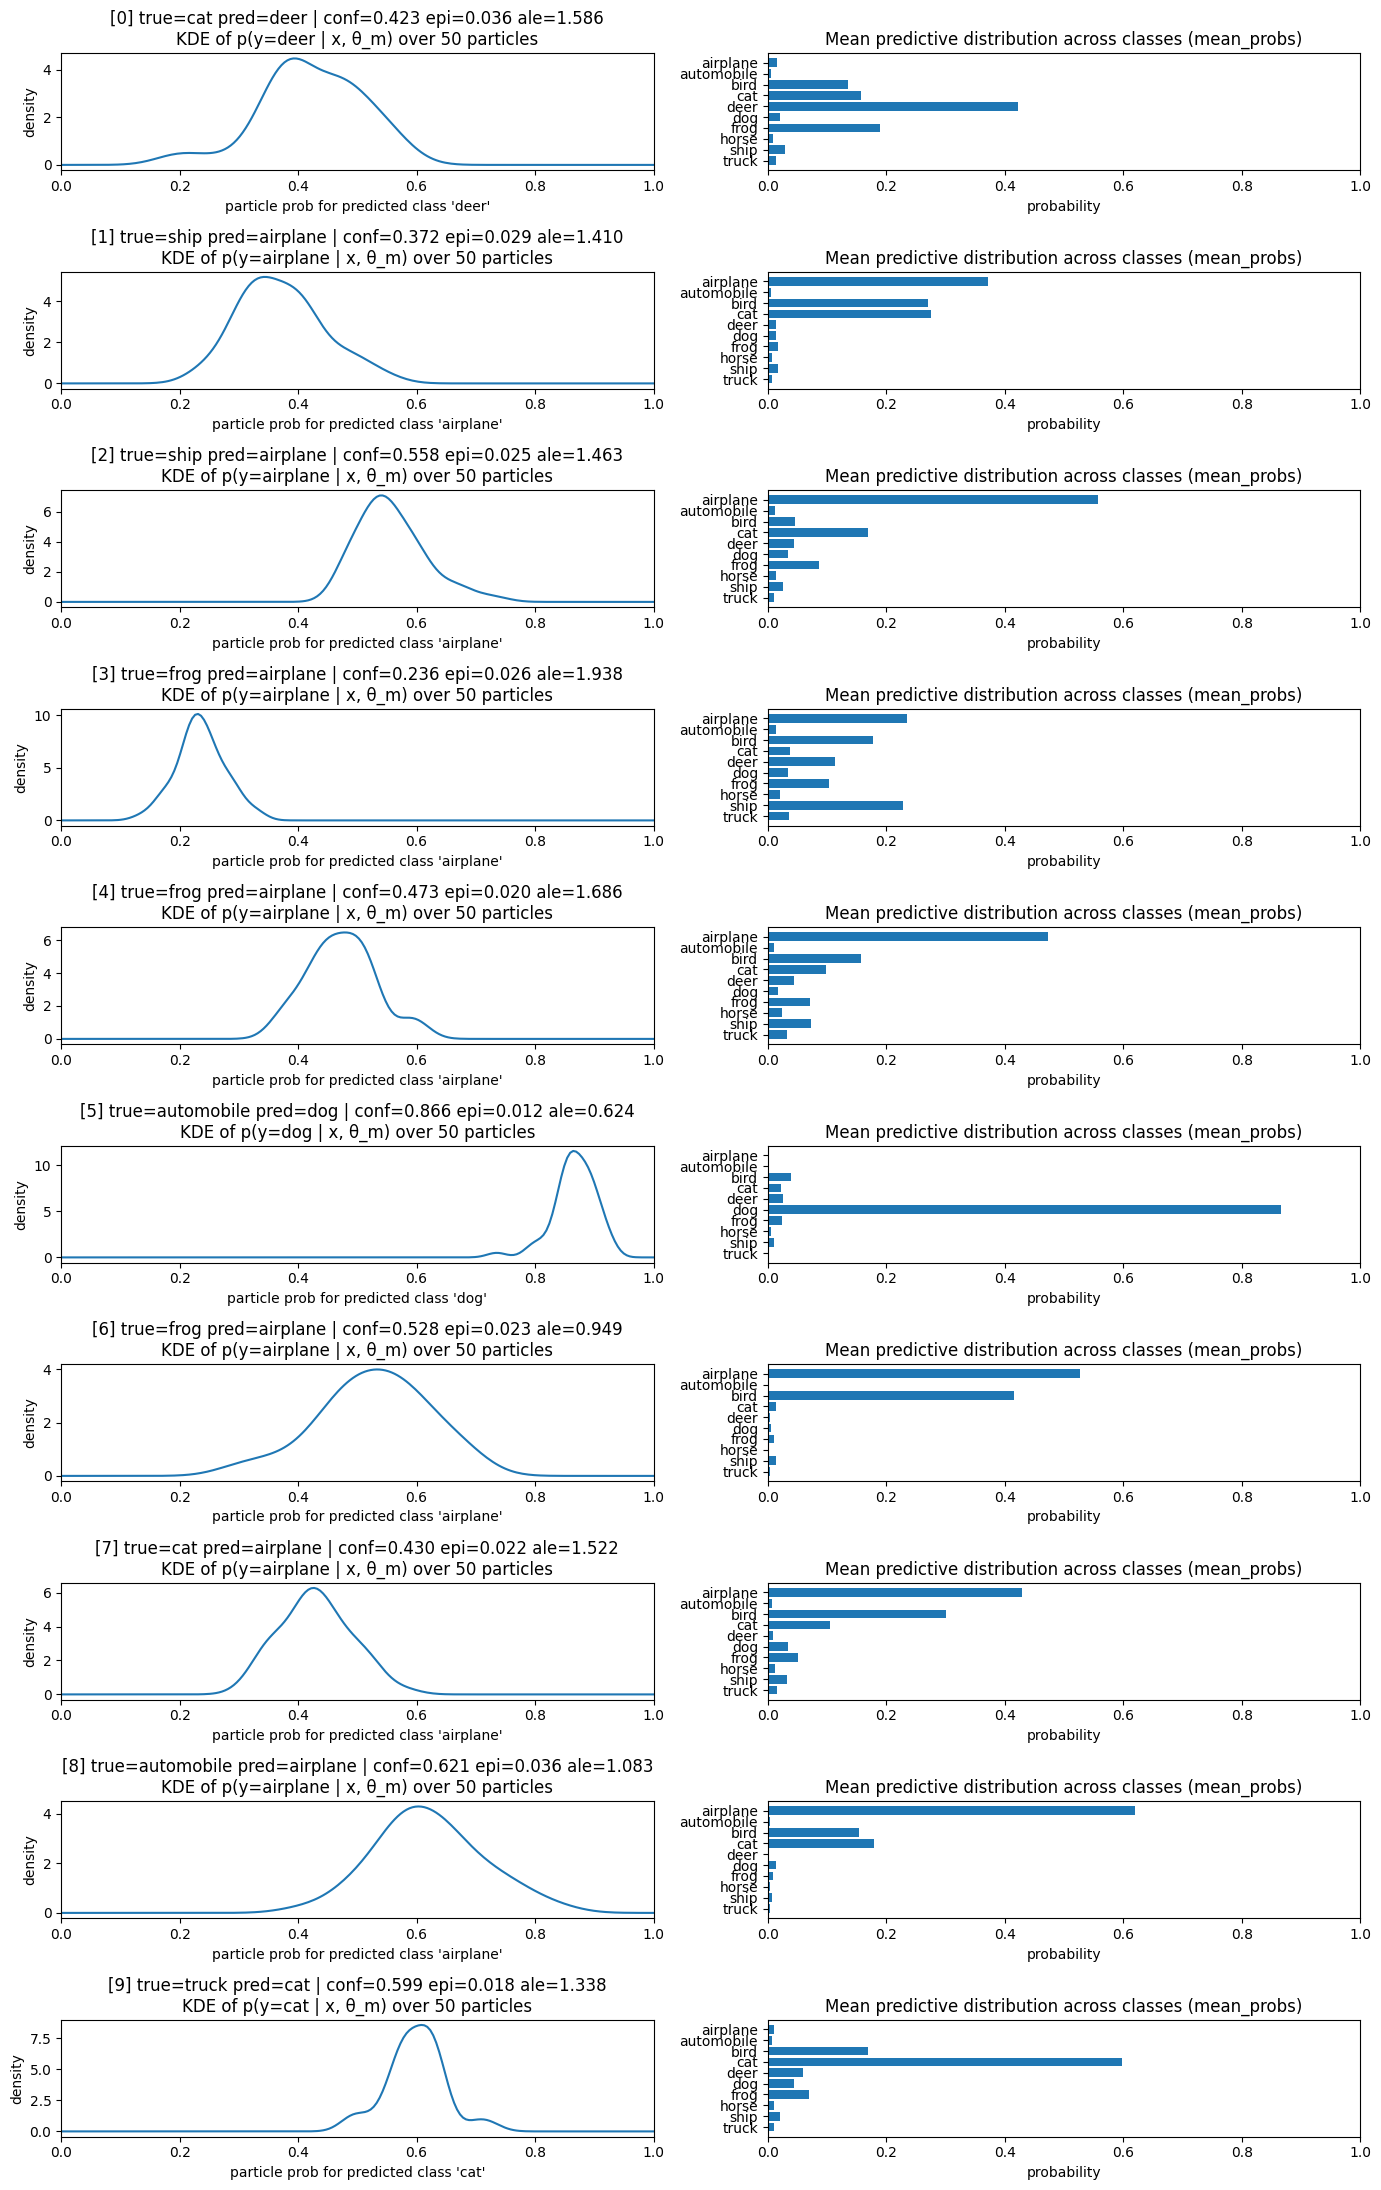

In [ ]:
results_ood

pred = results_ood["predictions"].detach().cpu()
true = data["test_labels"].detach().cpu()
wrong_idx = (pred != true).nonzero(as_tuple=True)[0]

print("Liczba błędów:", len(wrong_idx))
print("Pierwsze 10 błędnych indeksów:", wrong_idx[:10].tolist())

# weź pierwsze 10 błędnych przykładów i pokaż prezentację
idx10 = wrong_idx[:10]

fig = show_svgd_uncertainty_presentation(
    results={
        **results_ood,
        # pod-tnij wszystko co jest per-sample (N, ...) do wybranych indeksów
        "mean_probs": results_ood["mean_probs"][idx10],
        "particle_probs": results_ood["particle_probs"][:, idx10, :],
        "predictions": results_ood["predictions"][idx10],
        "confidence": results_ood["confidence"][idx10],
        "epistemic": results_ood["epistemic"][idx10],
        "aleatoric": results_ood["aleatoric"][idx10],
        "total_entropy": results_ood["total_entropy"][idx10],
    },
    labels=data["test_labels"][idx10],
    class_names=data["class_names"],
    n_show=len(idx10),
)

mean_p, H_pred, H_ale, H_epi = pred_ale_from_samples(results_ood["particle_probs"][:, idx10, :])

print("H_pred:", H_pred.item(), "H_ale:", H_ale.item(), "H_epi:", H_epi.item())
plt.show()

In [ ]:
def pred_ale_from_samples(sample_probs: torch.Tensor, eps: float = 1e-10):
    """
    sample_probs: (S, C) - każda próbka to rozkład po klasach (sum=1)
    zwraca: mean_probs (C,), H_pred (scalar), H_ale (scalar), H_epi (scalar)
    """
    p = sample_probs.clamp_min(eps)
    mean_p = p.mean(dim=0)  # (C,)

    H_pred = -(mean_p * mean_p.log()).sum()               # scalar
    H_each = -(p * p.log()).sum(dim=1)                    # (S,)
    H_ale  = H_each.mean()                                # scalar
    H_epi  = H_pred - H_ale

    return mean_p, H_pred, H_ale, H_epi
sample_probs = results["particle_probs"][:, 0, :]  # (50,10) lub (10,10)
mean_p, H_pred, H_ale, H_epi = pred_ale_from_samples(sample_probs)

print("H_pred:", H_pred.item(), "H_ale:", H_ale.item(), "H_epi:", H_epi.item())

H_pred: 0.008124219253659248 H_ale: 0.008001578971743584 H_epi: 0.00012264028191566467


In [ ]:
pred_ale_from_samples(results_ood["particle_probs"][:, idx10,0])

(tensor([0.0163, 0.3716, 0.5580, 0.2359, 0.4732, 0.0021, 0.5277, 0.4298, 0.6206,
         0.0103]),
 tensor(2.5114),
 tensor(2.4754),
 tensor(0.0360))